# Denoising Autoencoder and Variational Autoencoder (VAE)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


## Data Loading


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)

def add_noise(imgs, noise_level=0.5):
    return torch.clamp(imgs + noise_level * torch.randn_like(imgs), 0., 1.)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 5597291.27it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 239416.11it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 1967912.90it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 475906.29it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



## Denoising Autoencoder: Model Definition

In [3]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

### Training Loop

In [4]:
model = DenoisingAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss(reduction='sum')

for epoch in range(10):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        noisy_imgs = add_noise(imgs).to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")


Epoch 1, Loss: 1558.3047
Epoch 2, Loss: 783.5208
Epoch 3, Loss: 742.9399
Epoch 4, Loss: 722.6870
Epoch 5, Loss: 707.9317
Epoch 6, Loss: 693.5677
Epoch 7, Loss: 684.5950
Epoch 8, Loss: 674.6739
Epoch 9, Loss: 668.1029
Epoch 10, Loss: 663.5249


### Reconstruction Visualization


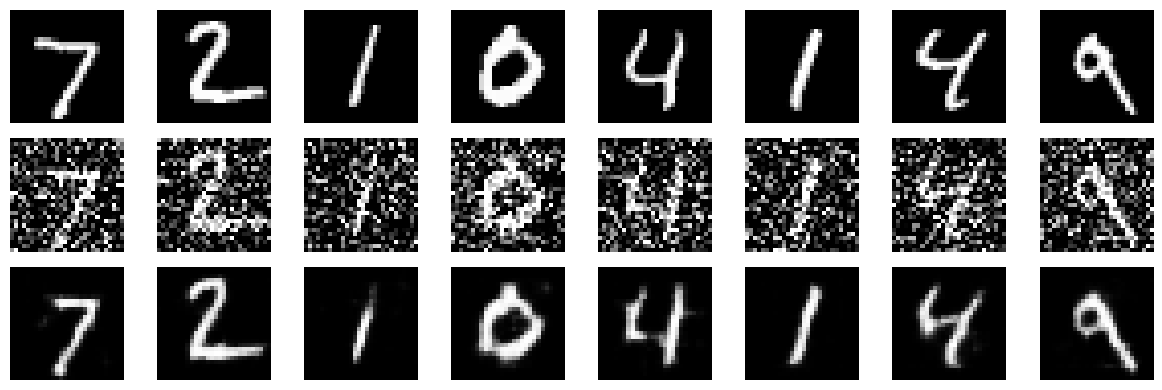

In [5]:
model.eval()
imgs, _ = next(iter(test_loader))
noisy_imgs = add_noise(imgs)

with torch.no_grad():
    recon = model(noisy_imgs.to(device)).cpu()

fig, axes = plt.subplots(3, 8, figsize=(12, 4))
for i in range(8):
    axes[0][i].imshow(imgs[i][0], cmap='gray'); axes[0][i].axis('off')
    axes[1][i].imshow(noisy_imgs[i][0], cmap='gray'); axes[1][i].axis('off')
    axes[2][i].imshow(recon[i][0], cmap='gray'); axes[2][i].axis('off')

axes[0][0].set_ylabel("Clean")
axes[1][0].set_ylabel("Noisy")
axes[2][0].set_ylabel("Recon")
plt.tight_layout()
plt.show()


## Variational Autoencoder (VAE)

In [6]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128*7*7, 20)
        self.fc_logvar = nn.Linear(128*7*7, 20)
        self.decoder_fc = nn.Linear(20, 128*7*7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    # Sampling is a random operation: we move the randomness inside an external variable (eps) so that
    # gradients can flow through mu and logvar, which are treated as trainable parameters
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def forward(self, x):
        enc = self.encoder(x).view(x.size(0), -1)
        mu = self.fc_mu(enc)
        logvar = self.fc_logvar(enc)
        z = self.reparameterize(mu, logvar)

        dec_input = self.decoder_fc(z).view(x.size(0), 128, 7, 7)

        return self.decoder(dec_input), mu, logvar


### Training Loop


In [7]:
def kl_divergence(mu, logvar):
    """
    Computes the KL divergence between N(mu, sigma^2) and N(0, 1)

    Args:
        mu (Tensor): Mean of latent distribution (batch_size, latent_dim)
        logvar (Tensor): Log-variance (log(sigma^2)) of latent distribution

    Returns:
        Tensor: Scalar KL divergence (summed over batch)
    """
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())


In [8]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
BCE= nn.BCELoss(reduction='sum')

for epoch in range(20):
    vae.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        recon, mu, logvar = vae(imgs)

        loss = BCE(recon, imgs) + kl_divergence(mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")


Epoch 1, Loss: 8234.5453
Epoch 2, Loss: 6879.4167
Epoch 3, Loss: 6737.2625
Epoch 4, Loss: 6654.3779
Epoch 5, Loss: 6597.9114
Epoch 6, Loss: 6553.7639
Epoch 7, Loss: 6515.3612
Epoch 8, Loss: 6486.7265
Epoch 9, Loss: 6460.8002
Epoch 10, Loss: 6440.2600
Epoch 11, Loss: 6418.8624
Epoch 12, Loss: 6405.6091
Epoch 13, Loss: 6390.8532
Epoch 14, Loss: 6376.7224
Epoch 15, Loss: 6364.8576
Epoch 16, Loss: 6349.9757
Epoch 17, Loss: 6340.0770
Epoch 18, Loss: 6333.8353
Epoch 19, Loss: 6323.9784
Epoch 20, Loss: 6314.7764


### New Data Generation


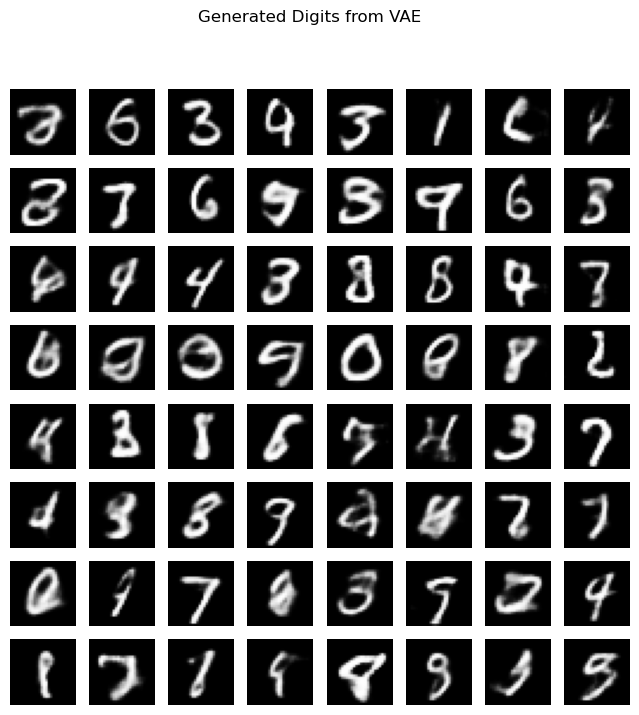

In [9]:
vae.eval()
with torch.no_grad():
    z = torch.randn(64, 20).to(device)
    dec = vae.decoder_fc(z).view(64, 128, 7, 7)
    gen_imgs = vae.decoder(dec).cpu()

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i in range(64):
    ax = axes[i//8][i%8]
    ax.imshow(gen_imgs[i][0], cmap='gray')
    ax.axis('off')
plt.suptitle("Generated Digits from VAE")
plt.show()
